# Proyecto 3 — Optimización de Pricing en Rutas de Ferry

## Notebook 1 — Generación y comprensión del dataset

En este notebook generamos un dataset simulado para analizar pricing, demanda, ocupación, ingresos y margen en una compañía ficticia de transporte marítimo: **Levante Ferries**.

El objetivo es construir una base de datos realista que nos permita desarrollar posteriormente:

- Análisis de precios.
- Análisis de demanda.
- Elasticidad precio-demanda.
- Modelos predictivos.
- Simulación de escenarios.
- Recomendaciones de pricing.
- Dashboard ejecutivo.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta
import os
import warnings

warnings.filterwarnings("ignore")

# Configuración visual
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [30]:
# ============================================================
# 2. CONEXIÓN CON GOOGLE DRIVE
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive conectado correctamente.")
except:
    print("No estás ejecutando este notebook en Google Colab o Drive ya está montado.")

No estás ejecutando este notebook en Google Colab o Drive ya está montado.


In [3]:
# ============================================================
# 3. CREACIÓN DE CARPETAS DEL PROYECTO
# ============================================================

base_path = "/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing"

folders = [
    base_path,
    f"{base_path}/data",
    f"{base_path}/data/raw",
    f"{base_path}/data/processed",
    f"{base_path}/notebooks",
    f"{base_path}/dashboard",
    f"{base_path}/reports",
    f"{base_path}/images"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Estructura de carpetas creada correctamente:")
for folder in folders:
    print(folder)

Estructura de carpetas creada correctamente:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/raw
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/notebooks
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/dashboard
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/images


In [4]:
# ============================================================
# 4. CATÁLOGO DE RUTAS
# ============================================================

routes_config = [
    {
        "route": "Denia-Ibiza",
        "origin": "Denia",
        "destination": "Ibiza",
        "route_type": "Inter-island / Mainland-Island",
        "vessel_type": "Fast Ferry",
        "capacity": 350,
        "base_price": 58,
        "base_demand": 250,
        "fixed_operational_cost": 14500,
        "variable_cost_per_passenger": 8,
        "elasticity": -0.85,
        "departures": [8, 14, 20]
    },
    {
        "route": "Denia-Formentera",
        "origin": "Denia",
        "destination": "Formentera",
        "route_type": "Mainland-Island",
        "vessel_type": "Fast Ferry",
        "capacity": 280,
        "base_price": 72,
        "base_demand": 190,
        "fixed_operational_cost": 13200,
        "variable_cost_per_passenger": 7,
        "elasticity": -0.75,
        "departures": [9, 17]
    },
    {
        "route": "Denia-Mallorca",
        "origin": "Denia",
        "destination": "Mallorca",
        "route_type": "Mainland-Island",
        "vessel_type": "Ro-Pax",
        "capacity": 520,
        "base_price": 64,
        "base_demand": 310,
        "fixed_operational_cost": 22500,
        "variable_cost_per_passenger": 10,
        "elasticity": -0.95,
        "departures": [11, 22]
    },
    {
        "route": "Valencia-Ibiza",
        "origin": "Valencia",
        "destination": "Ibiza",
        "route_type": "Mainland-Island",
        "vessel_type": "Ro-Pax",
        "capacity": 620,
        "base_price": 69,
        "base_demand": 390,
        "fixed_operational_cost": 25500,
        "variable_cost_per_passenger": 11,
        "elasticity": -0.90,
        "departures": [10, 23]
    },
    {
        "route": "Valencia-Mallorca",
        "origin": "Valencia",
        "destination": "Mallorca",
        "route_type": "Mainland-Island",
        "vessel_type": "Ro-Pax",
        "capacity": 700,
        "base_price": 62,
        "base_demand": 440,
        "fixed_operational_cost": 27500,
        "variable_cost_per_passenger": 12,
        "elasticity": -1.05,
        "departures": [8, 16, 23]
    },
    {
        "route": "Ibiza-Mallorca",
        "origin": "Ibiza",
        "destination": "Mallorca",
        "route_type": "Inter-island",
        "vessel_type": "Fast Ferry",
        "capacity": 300,
        "base_price": 49,
        "base_demand": 180,
        "fixed_operational_cost": 11800,
        "variable_cost_per_passenger": 7,
        "elasticity": -1.15,
        "departures": [7, 13, 19]
    }
]

routes_df = pd.DataFrame(routes_config)

routes_df

,route,origin,destination,route_type,vessel_type,capacity,base_price,base_demand,fixed_operational_cost,variable_cost_per_passenger,elasticity,departures
0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,58,250,14500,8,-0.85,"[8, 14, 20]"
1,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,72,190,13200,7,-0.75,"[9, 17]"
2,Denia-Mallorca,Denia,Mallorca,Mainland-Island,Ro-Pax,520,64,310,22500,10,-0.95,"[11, 22]"
3,Valencia-Ibiza,Valencia,Ibiza,Mainland-Island,Ro-Pax,620,69,390,25500,11,-0.90,"[10, 23]"
4,Valencia-Mallorca,Valencia,Mallorca,Mainland-Island,Ro-Pax,700,62,440,27500,12,-1.05,"[8, 16, 23]"
5,Ibiza-Mallorca,Ibiza,Mallorca,Inter-island,Fast Ferry,300,49,180,11800,7,-1.15,"[7, 13, 19]"


In [5]:
# ============================================================
# 5. FUNCIONES AUXILIARES
# ============================================================

def get_season(date):
    """
    Clasifica la fecha en temporada baja, media o alta.
    """
    month = date.month

    if month in [7, 8]:
        return "High"
    elif month in [4, 5, 6, 9, 10]:
        return "Shoulder"
    else:
        return "Low"


def get_season_factor(season):
    """
    Factor de demanda según temporada.
    """
    factors = {
        "Low": 0.72,
        "Shoulder": 1.00,
        "High": 1.38
    }
    return factors.get(season, 1.00)


def get_price_season_factor(season):
    """
    Factor de precio según temporada.
    """
    factors = {
        "Low": 0.88,
        "Shoulder": 1.00,
        "High": 1.28
    }
    return factors.get(season, 1.00)


def get_day_factor(day_of_week):
    """
    Factor de demanda según día de la semana.
    """
    if day_of_week in ["Friday", "Saturday", "Sunday"]:
        return 1.18
    elif day_of_week == "Monday":
        return 0.92
    else:
        return 1.00


def get_hour_factor(hour):
    """
    Factor de demanda según hora de salida.
    """
    if 7 <= hour <= 10:
        return 1.08
    elif 11 <= hour <= 17:
        return 1.00
    elif 18 <= hour <= 21:
        return 1.12
    else:
        return 0.86


def get_booking_window(days_before_departure):
    """
    Clasifica la antelación media de compra.
    """
    if days_before_departure <= 3:
        return "Last minute"
    elif days_before_departure <= 14:
        return "Short"
    elif days_before_departure <= 45:
        return "Medium"
    else:
        return "Early"


def classify_demand_level(occupancy_rate):
    """
    Clasifica el nivel de demanda según ocupación.
    """
    if occupancy_rate >= 0.85:
        return "Very High"
    elif occupancy_rate >= 0.70:
        return "High"
    elif occupancy_rate >= 0.50:
        return "Medium"
    else:
        return "Low"


def classify_pricing_opportunity(occupancy_rate, margin_pct, elasticity):
    """
    Clasifica oportunidades de pricing de forma sencilla.
    """
    if occupancy_rate >= 0.85 and elasticity > -1 and margin_pct >= 0.25:
        return "Potential price increase"
    elif occupancy_rate >= 0.85 and margin_pct < 0.20:
        return "High demand but low margin"
    elif occupancy_rate < 0.55 and elasticity <= -1:
        return "Promotion opportunity"
    elif occupancy_rate < 0.55 and margin_pct >= 0.30:
        return "Review demand generation"
    else:
        return "Maintain / Monitor"


print("Funciones auxiliares creadas correctamente.")

Funciones auxiliares creadas correctamente.


In [6]:
# ============================================================
# 6. GENERACIÓN DEL CALENDARIO DE VIAJES
# ============================================================

np.random.seed(42)

start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31)

date_range = pd.date_range(start=start_date, end=end_date, freq="D")

trips = []

trip_counter = 1

for current_date in date_range:
    for route_info in routes_config:
        for departure_hour in route_info["departures"]:

            departure_datetime = datetime(
                current_date.year,
                current_date.month,
                current_date.day,
                departure_hour,
                0
            )

            trips.append({
                "trip_id": f"TRIP_{trip_counter:06d}",
                "trip_date": current_date.date(),
                "departure_datetime": departure_datetime,
                "route": route_info["route"],
                "origin": route_info["origin"],
                "destination": route_info["destination"],
                "route_type": route_info["route_type"],
                "vessel_type": route_info["vessel_type"],
                "capacity": route_info["capacity"],
                "departure_hour": departure_hour,
                "base_price": route_info["base_price"],
                "base_demand": route_info["base_demand"],
                "fixed_operational_cost": route_info["fixed_operational_cost"],
                "variable_cost_per_passenger": route_info["variable_cost_per_passenger"],
                "route_elasticity": route_info["elasticity"]
            })

            trip_counter += 1

df = pd.DataFrame(trips)

print(f"Número total de viajes generados: {len(df):,}")
df.head()

Número total de viajes generados: 5,475


,trip_id,trip_date,departure_datetime,route,origin,destination,route_type,vessel_type,capacity,departure_hour,base_price,base_demand,fixed_operational_cost,variable_cost_per_passenger,route_elasticity
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,8,58,250,14500,8,-0.85
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,14,58,250,14500,8,-0.85
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,20,58,250,14500,8,-0.85
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,9,72,190,13200,7,-0.75
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,17,72,190,13200,7,-0.75


In [7]:
# ============================================================
# 7. VARIABLES TEMPORALES
# ============================================================

df["trip_date"] = pd.to_datetime(df["trip_date"])
df["departure_datetime"] = pd.to_datetime(df["departure_datetime"])

df["year"] = df["trip_date"].dt.year
df["month"] = df["trip_date"].dt.month
df["week"] = df["trip_date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["trip_date"].dt.day_name()
df["is_weekend"] = df["day_of_week"].isin(["Friday", "Saturday", "Sunday"]).astype(int)

df["season"] = df["trip_date"].apply(get_season)
df["high_season_flag"] = (df["season"] == "High").astype(int)

df.head()


,trip_id,trip_date,departure_datetime,route,origin,destination,route_type,vessel_type,capacity,departure_hour,base_price,base_demand,fixed_operational_cost,variable_cost_per_passenger,route_elasticity,year,month,week,day_of_week,is_weekend,season,high_season_flag
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,8,58,250,14500,8,-0.85,2025,1,1,Wednesday,0,Low,0
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,14,58,250,14500,8,-0.85,2025,1,1,Wednesday,0,Low,0
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,20,58,250,14500,8,-0.85,2025,1,1,Wednesday,0,Low,0
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,9,72,190,13200,7,-0.75,2025,1,1,Wednesday,0,Low,0
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,17,72,190,13200,7,-0.75,2025,1,1,Wednesday,0,Low,0


In [8]:
# ============================================================
# 8. VARIABLES EXTERNAS
# ============================================================

# Weather score: 1 muy malo, 10 excelente
df["weather_score"] = np.random.normal(loc=7.2, scale=1.4, size=len(df))
df["weather_score"] = df["weather_score"].clip(1, 10).round(1)

# Probabilidad de evento según temporada y fin de semana
event_probability = np.where(
    df["season"] == "High",
    0.18,
    np.where(df["season"] == "Shoulder", 0.08, 0.03)
)

event_probability = np.where(
    df["is_weekend"] == 1,
    event_probability + 0.05,
    event_probability
)

df["event_flag"] = np.random.binomial(1, event_probability)

# Antelación media de compra
df["days_before_departure"] = np.random.gamma(shape=3.2, scale=7.5, size=len(df)).round().astype(int)
df["days_before_departure"] = df["days_before_departure"].clip(1, 90)

df["booking_window"] = df["days_before_departure"].apply(get_booking_window)

df[[
    "trip_id",
    "route",
    "trip_date",
    "season",
    "is_weekend",
    "weather_score",
    "event_flag",
    "days_before_departure",
    "booking_window"
]].head()

,trip_id,route,trip_date,season,is_weekend,weather_score,event_flag,days_before_departure,booking_window
0,TRIP_000001,Denia-Ibiza,2025-01-01,Low,0,7.9,0,50,Early
1,TRIP_000002,Denia-Ibiza,2025-01-01,Low,0,7.0,0,34,Medium
2,TRIP_000003,Denia-Ibiza,2025-01-01,Low,0,8.1,0,9,Short
3,TRIP_000004,Denia-Formentera,2025-01-01,Low,0,9.3,0,24,Medium
4,TRIP_000005,Denia-Formentera,2025-01-01,Low,0,6.9,0,36,Medium


In [9]:
# ============================================================
# 9. SIMULACIÓN DE PRECIOS
# ============================================================

# Factor por temporada
df["season_price_factor"] = df["season"].apply(get_price_season_factor)

# Factor por antelación:
# Si queda poco tiempo para la salida, el precio tiende a ser mayor.
df["booking_price_factor"] = np.where(
    df["days_before_departure"] <= 3,
    1.22,
    np.where(
        df["days_before_departure"] <= 14,
        1.10,
        np.where(df["days_before_departure"] <= 45, 1.00, 0.92)
    )
)

# Factor fin de semana
df["weekend_price_factor"] = np.where(df["is_weekend"] == 1, 1.08, 1.00)

# Factor evento
df["event_price_factor"] = np.where(df["event_flag"] == 1, 1.15, 1.00)

# Ruido comercial controlado
df["price_noise"] = np.random.normal(loc=1.00, scale=0.06, size=len(df))

# Precio medio del billete
df["avg_ticket_price"] = (
    df["base_price"]
    * df["season_price_factor"]
    * df["booking_price_factor"]
    * df["weekend_price_factor"]
    * df["event_price_factor"]
    * df["price_noise"]
)

df["avg_ticket_price"] = df["avg_ticket_price"].round(2)

# Precio del competidor simulado
df["competitor_price"] = (
    df["avg_ticket_price"] * np.random.normal(loc=0.98, scale=0.08, size=len(df))
).round(2)

df["price_index_vs_competitor"] = (df["avg_ticket_price"] / df["competitor_price"]).round(3)

df[[
    "route",
    "season",
    "booking_window",
    "event_flag",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor"
]].head()

,route,season,booking_window,event_flag,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor
0,Denia-Ibiza,Low,Early,0,58,44.76,42.02,1.065
1,Denia-Ibiza,Low,Medium,0,58,57.35,57.26,1.002
2,Denia-Ibiza,Low,Short,0,58,56.78,62.52,0.908
3,Denia-Formentera,Low,Medium,0,72,66.93,66.98,0.999
4,Denia-Formentera,Low,Medium,0,72,64.16,63.41,1.012


In [10]:
# ============================================================
# 10. SIMULACIÓN DE DEMANDA
# ============================================================

# Factores de demanda
df["season_demand_factor"] = df["season"].apply(get_season_factor)
df["day_demand_factor"] = df["day_of_week"].apply(get_day_factor)
df["hour_demand_factor"] = df["departure_hour"].apply(get_hour_factor)

# Factor meteorológico
df["weather_demand_factor"] = 0.75 + (df["weather_score"] / 10) * 0.35

# Factor evento
df["event_demand_factor"] = np.where(df["event_flag"] == 1, 1.18, 1.00)

# Efecto precio según elasticidad
df["price_demand_factor"] = (
    df["avg_ticket_price"] / df["base_price"]
) ** df["route_elasticity"]

# Ruido de demanda
df["demand_noise"] = np.random.normal(loc=1.00, scale=0.12, size=len(df))

# Demanda esperada
df["expected_demand"] = (
    df["base_demand"]
    * df["season_demand_factor"]
    * df["day_demand_factor"]
    * df["hour_demand_factor"]
    * df["weather_demand_factor"]
    * df["event_demand_factor"]
    * df["price_demand_factor"]
    * df["demand_noise"]
)

df["expected_demand"] = df["expected_demand"].round().astype(int)
df["expected_demand"] = df["expected_demand"].clip(lower=0)

# Tickets vendidos: no pueden superar la capacidad
df["tickets_sold"] = np.minimum(df["expected_demand"], df["capacity"])

# Ocupación
df["occupancy_rate"] = (df["tickets_sold"] / df["capacity"]).round(4)

df[[
    "route",
    "season",
    "capacity",
    "avg_ticket_price",
    "route_elasticity",
    "base_demand",
    "expected_demand",
    "tickets_sold",
    "occupancy_rate"
]].head()

,route,season,capacity,avg_ticket_price,route_elasticity,base_demand,expected_demand,tickets_sold,occupancy_rate
0,Denia-Ibiza,Low,350,44.76,-0.85,250,189,189,0.5400
1,Denia-Ibiza,Low,350,57.35,-0.85,250,160,160,0.4571
2,Denia-Ibiza,Low,350,56.78,-0.85,250,195,195,0.5571
3,Denia-Formentera,Low,280,66.93,-0.75,190,160,160,0.5714
4,Denia-Formentera,Low,280,64.16,-0.75,190,131,131,0.4679


In [11]:
# ============================================================
# 11. REVENUE, COSTES Y MARGEN
# ============================================================

# Ingresos
df["revenue"] = (df["tickets_sold"] * df["avg_ticket_price"]).round(2)

# Coste operativo total
df["total_operational_cost"] = (
    df["fixed_operational_cost"]
    + df["tickets_sold"] * df["variable_cost_per_passenger"]
).round(2)

# Margen absoluto
df["margin"] = (df["revenue"] - df["total_operational_cost"]).round(2)

# Margen porcentual
df["margin_pct"] = np.where(
    df["revenue"] > 0,
    df["margin"] / df["revenue"],
    0
)

df["margin_pct"] = df["margin_pct"].round(4)

df[[
    "route",
    "tickets_sold",
    "occupancy_rate",
    "avg_ticket_price",
    "revenue",
    "total_operational_cost",
    "margin",
    "margin_pct"
]].head()

,route,tickets_sold,occupancy_rate,avg_ticket_price,revenue,total_operational_cost,margin,margin_pct
0,Denia-Ibiza,189,0.5400,44.76,8459.64,16012,-7552.36,-0.8928
1,Denia-Ibiza,160,0.4571,57.35,9176.00,15780,-6604.00,-0.7197
2,Denia-Ibiza,195,0.5571,56.78,11072.10,16060,-4987.90,-0.4505
3,Denia-Formentera,160,0.5714,66.93,10708.80,14320,-3611.20,-0.3372
4,Denia-Formentera,131,0.4679,64.16,8404.96,14117,-5712.04,-0.6796


In [12]:
# ============================================================
# 12. VARIABLES DE NEGOCIO
# ============================================================

df["demand_level"] = df["occupancy_rate"].apply(classify_demand_level)

df["pricing_opportunity"] = df.apply(
    lambda row: classify_pricing_opportunity(
        row["occupancy_rate"],
        row["margin_pct"],
        row["route_elasticity"]
    ),
    axis=1
)

# Variable combinada útil para análisis y dashboard
df["trip_feature"] = (
    df["route"]
    + " | "
    + df["season"]
    + " | "
    + df["day_of_week"]
    + " | "
    + df["booking_window"]
)

df[[
    "route",
    "season",
    "day_of_week",
    "booking_window",
    "occupancy_rate",
    "margin_pct",
    "demand_level",
    "pricing_opportunity",
    "trip_feature"
]].head()

,route,season,day_of_week,booking_window,occupancy_rate,margin_pct,demand_level,pricing_opportunity,trip_feature
0,Denia-Ibiza,Low,Wednesday,Early,0.5400,-0.8928,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,Denia-Ibiza,Low,Wednesday,Medium,0.4571,-0.7197,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,Denia-Ibiza,Low,Wednesday,Short,0.5571,-0.4505,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,Denia-Formentera,Low,Wednesday,Medium,0.5714,-0.3372,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,Denia-Formentera,Low,Wednesday,Medium,0.4679,-0.6796,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [13]:
# ============================================================
# 13. SELECCIÓN DE COLUMNAS FINALES
# ============================================================

final_columns = [
    "trip_id",
    "trip_date",
    "departure_datetime",
    "year",
    "month",
    "week",
    "day_of_week",
    "is_weekend",
    "season",
    "high_season_flag",
    "route",
    "origin",
    "destination",
    "route_type",
    "vessel_type",
    "departure_hour",
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "booking_window",
    "weather_score",
    "event_flag",
    "expected_demand",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "fixed_operational_cost",
    "variable_cost_per_passenger",
    "total_operational_cost",
    "margin",
    "margin_pct",
    "demand_level",
    "pricing_opportunity",
    "trip_feature"
]

df_final = df[final_columns].copy()

print(f"Filas finales: {df_final.shape[0]:,}")
print(f"Columnas finales: {df_final.shape[1]:,}")

df_final.head()

Filas finales: 5,475
Columnas finales: 38


,trip_id,trip_date,departure_datetime,year,month,week,day_of_week,is_weekend,season,high_season_flag,route,origin,destination,route_type,vessel_type,departure_hour,capacity,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor,route_elasticity,days_before_departure,booking_window,weather_score,event_flag,expected_demand,tickets_sold,occupancy_rate,revenue,fixed_operational_cost,variable_cost_per_passenger,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity,trip_feature
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,8,350,58,44.76,42.02,1.065,-0.85,50,Early,7.9,0,189,189,0.5400,8459.64,14500,8,16012,-7552.36,-0.8928,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,14,350,58,57.35,57.26,1.002,-0.85,34,Medium,7.0,0,160,160,0.4571,9176.00,14500,8,15780,-6604.00,-0.7197,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,20,350,58,56.78,62.52,0.908,-0.85,9,Short,8.1,0,195,195,0.5571,11072.10,14500,8,16060,-4987.90,-0.4505,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,9,280,72,66.93,66.98,0.999,-0.75,24,Medium,9.3,0,160,160,0.5714,10708.80,13200,7,14320,-3611.20,-0.3372,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,17,280,72,64.16,63.41,1.012,-0.75,36,Medium,6.9,0,131,131,0.4679,8404.96,13200,7,14117,-5712.04,-0.6796,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [14]:
# ============================================================
# 14. REVISIÓN GENERAL
# ============================================================

df_final.info()
df_final.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   trip_id                      5475 non-null   object        
 1   trip_date                    5475 non-null   datetime64[ns]
 2   departure_datetime           5475 non-null   datetime64[ns]
 3   year                         5475 non-null   int32         
 4   month                        5475 non-null   int32         
 5   week                         5475 non-null   int64         
 6   day_of_week                  5475 non-null   object        
 7   is_weekend                   5475 non-null   int64         
 8   season                       5475 non-null   object        
 9   high_season_flag             5475 non-null   int64         
 10  route                        5475 non-null   object        
 11  origin                       5475 non-null 

,count,mean,min,25%,50%,75%,max,std
trip_date,5475,2025-07-02 00:00:00,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
departure_datetime,5475,2025-07-02 14:39:59.999999744,2025-01-01 07:00:00,2025-04-02 09:30:00,2025-07-02 14:00:00,2025-10-01 19:30:00,2025-12-31 23:00:00,NaN
year,5475.0,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,0.0
month,5475.0,6.526027,1.0,4.0,7.0,10.0,12.0,3.448166
week,5475.0,26.430137,1.0,13.0,26.0,39.0,52.0,15.048284
is_weekend,5475.0,0.427397,0.0,0.0,0.0,1.0,1.0,0.494746
high_season_flag,5475.0,0.169863,0.0,0.0,0.0,0.0,1.0,0.375547
departure_hour,5475.0,14.666667,7.0,9.0,14.0,20.0,23.0,5.570268
capacity,5475.0,459.333333,280.0,300.0,350.0,620.0,700.0,165.160138
base_price,5475.0,61.133333,49.0,58.0,62.0,69.0,72.0,7.527233


In [15]:
# ============================================================
# 15. VALIDACIONES DE NEGOCIO
# ============================================================

print("Validación 1: tickets_sold nunca debe superar capacity")
print((df_final["tickets_sold"] <= df_final["capacity"]).all())

print("\nValidación 2: occupancy_rate debe estar entre 0 y 1")
print(df_final["occupancy_rate"].between(0, 1).all())

print("\nValidación 3: revenue no debe ser negativo")
print((df_final["revenue"] >= 0).all())

print("\nValidación 4: avg_ticket_price debe ser positivo")
print((df_final["avg_ticket_price"] > 0).all())

print("\nValidación 5: no debería haber nulos")
print(df_final.isnull().sum().sum() == 0)

Validación 1: tickets_sold nunca debe superar capacity
True

Validación 2: occupancy_rate debe estar entre 0 y 1
True

Validación 3: revenue no debe ser negativo
True

Validación 4: avg_ticket_price debe ser positivo
True

Validación 5: no debería haber nulos
True


In [16]:
# ============================================================
# 16. KPIs GENERALES
# ============================================================

total_revenue = df_final["revenue"].sum()
total_margin = df_final["margin"].sum()
avg_occupancy = df_final["occupancy_rate"].mean()
avg_ticket_price = df_final["avg_ticket_price"].mean()
total_tickets = df_final["tickets_sold"].sum()
num_trips = df_final["trip_id"].nunique()

print("KPIs GENERALES DEL DATASET")
print("-" * 40)
print(f"Número de viajes: {num_trips:,.0f}")
print(f"Tickets vendidos: {total_tickets:,.0f}")
print(f"Revenue total: {total_revenue:,.2f} €")
print(f"Margen total: {total_margin:,.2f} €")
print(f"Ocupación media: {avg_occupancy:.2%}")
print(f"Precio medio ticket: {avg_ticket_price:.2f} €")

KPIs GENERALES DEL DATASET
----------------------------------------
Número de viajes: 5,475
Tickets vendidos: 1,535,436
Revenue total: 102,998,839.77 €
Margen total: -15,536,685.23 €
Ocupación media: 62.43%
Precio medio ticket: 65.39 €


In [17]:
# ============================================================
# 17. RESUMEN POR RUTA
# ============================================================

route_summary = (
    df_final
    .groupby("route")
    .agg(
        trips=("trip_id", "count"),
        avg_capacity=("capacity", "mean"),
        tickets_sold=("tickets_sold", "sum"),
        avg_occupancy=("occupancy_rate", "mean"),
        avg_ticket_price=("avg_ticket_price", "mean"),
        total_revenue=("revenue", "sum"),
        total_margin=("margin", "sum"),
        avg_margin_pct=("margin_pct", "mean"),
        elasticity=("route_elasticity", "mean")
    )
    .reset_index()
)

route_summary["avg_occupancy"] = route_summary["avg_occupancy"].round(3)
route_summary["avg_ticket_price"] = route_summary["avg_ticket_price"].round(2)
route_summary["total_revenue"] = route_summary["total_revenue"].round(2)
route_summary["total_margin"] = route_summary["total_margin"].round(2)
route_summary["avg_margin_pct"] = route_summary["avg_margin_pct"].round(3)

route_summary.sort_values("total_revenue", ascending=False)

,route,trips,avg_capacity,tickets_sold,avg_occupancy,avg_ticket_price,total_revenue,total_margin,avg_margin_pct,elasticity
5,Valencia-Mallorca,1095,700.0,450836,0.588,66.26,30124521.77,-5398010.23,-0.287,-1.05
4,Valencia-Ibiza,730,620.0,265104,0.586,74.19,19932754.20,-1598389.80,-0.193,-0.90
1,Denia-Ibiza,1095,350.0,278611,0.727,62.08,17529547.37,-576840.63,-0.131,-0.85
2,Denia-Mallorca,730,520.0,202422,0.533,68.51,14072473.81,-4376746.19,-0.439,-0.95
0,Denia-Formentera,730,280.0,138719,0.679,76.70,10829083.52,222050.52,-0.083,-0.75
3,Ibiza-Mallorca,1095,300.0,199744,0.608,52.33,10510459.10,-3808748.90,-0.466,-1.15


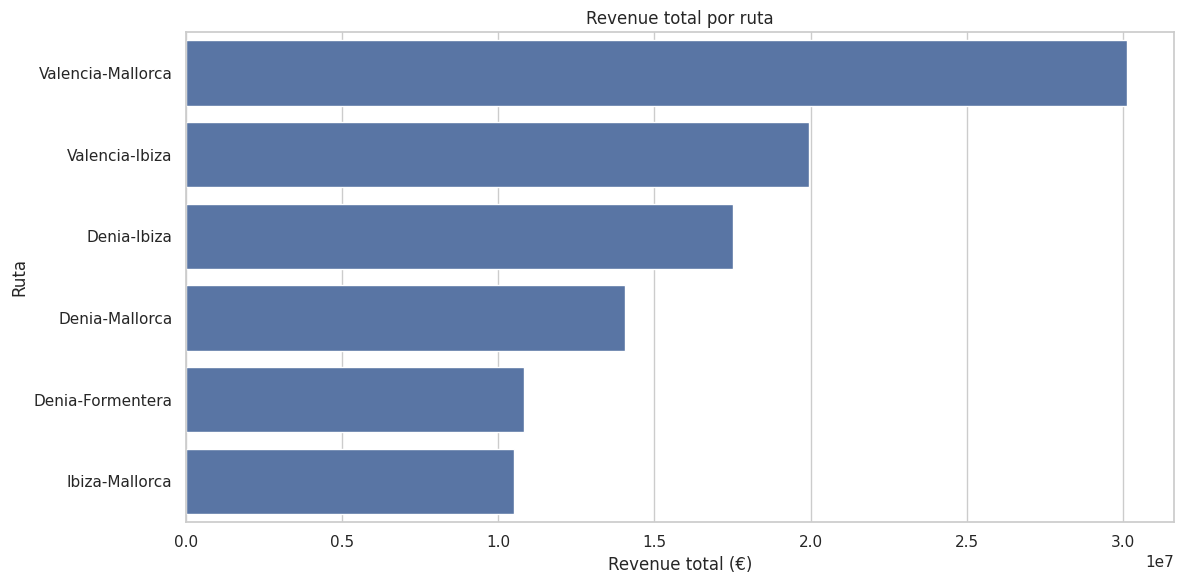

In [18]:
# ============================================================
# 18. GRÁFICO: REVENUE POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

route_revenue = (
    df_final
    .groupby("route")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_revenue.values,
    y=route_revenue.index
)

plt.title("Revenue total por ruta")
plt.xlabel("Revenue total (€)")
plt.ylabel("Ruta")
plt.tight_layout()
plt.show()

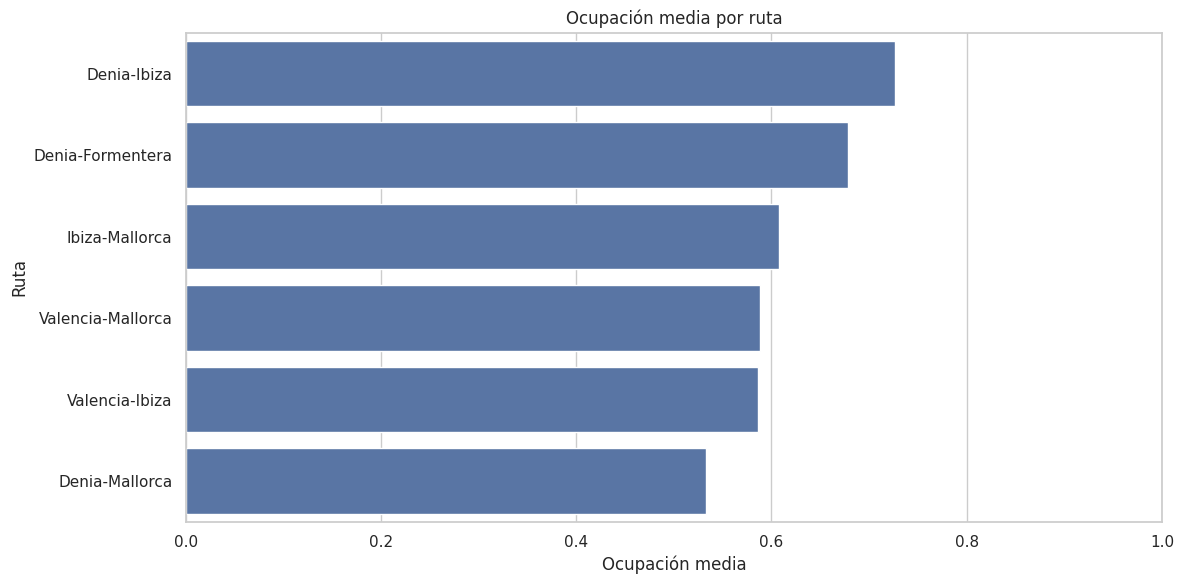

In [19]:
# ============================================================
# 19. GRÁFICO: OCUPACIÓN MEDIA POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

route_occupancy = (
    df_final
    .groupby("route")["occupancy_rate"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=route_occupancy.values,
    y=route_occupancy.index
)

plt.title("Ocupación media por ruta")
plt.xlabel("Ocupación media")
plt.ylabel("Ruta")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

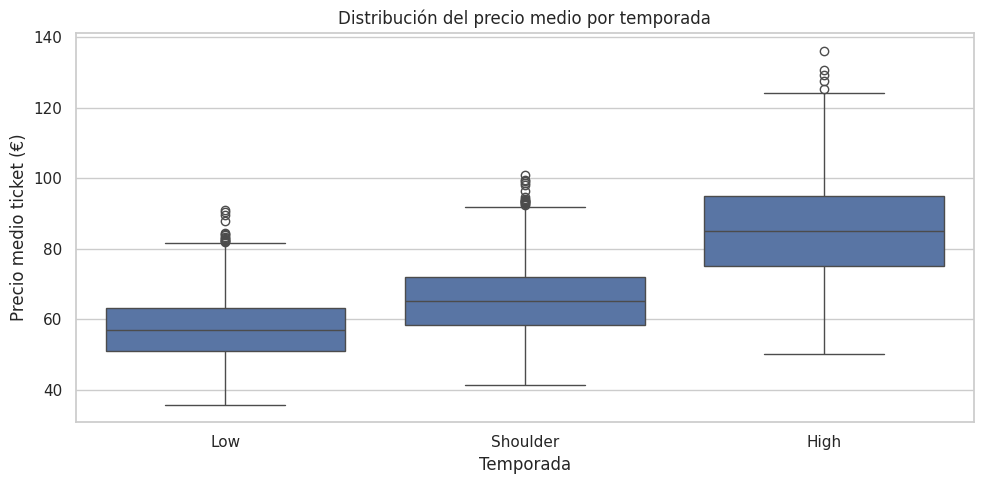

In [20]:
# ============================================================
# 20. GRÁFICO: PRECIO MEDIO POR TEMPORADA
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_final,
    x="season",
    y="avg_ticket_price",
    order=["Low", "Shoulder", "High"]
)

plt.title("Distribución del precio medio por temporada")
plt.xlabel("Temporada")
plt.ylabel("Precio medio ticket (€)")
plt.tight_layout()
plt.show()

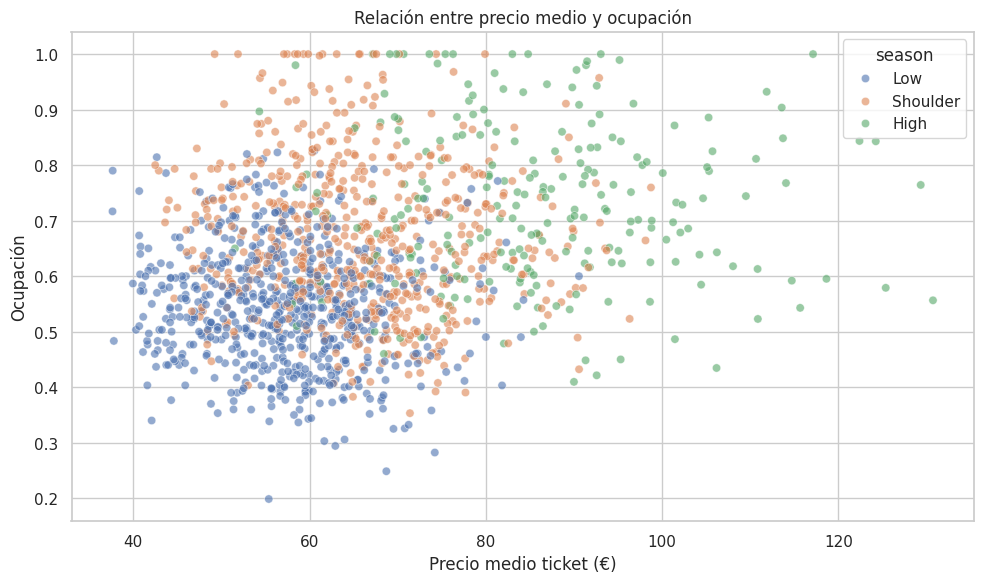

In [21]:
# ============================================================
# 21. GRÁFICO: PRECIO VS OCUPACIÓN
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_final.sample(1500, random_state=42),
    x="avg_ticket_price",
    y="occupancy_rate",
    hue="season",
    alpha=0.6
)

plt.title("Relación entre precio medio y ocupación")
plt.xlabel("Precio medio ticket (€)")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 22. DISTRIBUCIÓN DE OPORTUNIDADES DE PRICING
# ============================================================

pricing_counts = (
    df_final["pricing_opportunity"]
    .value_counts()
    .reset_index()
)

pricing_counts.columns = ["pricing_opportunity", "count"]

pricing_counts

,pricing_opportunity,count
0,Maintain / Monitor,4305
1,Promotion opportunity,795
2,Potential price increase,203
3,High demand but low margin,172


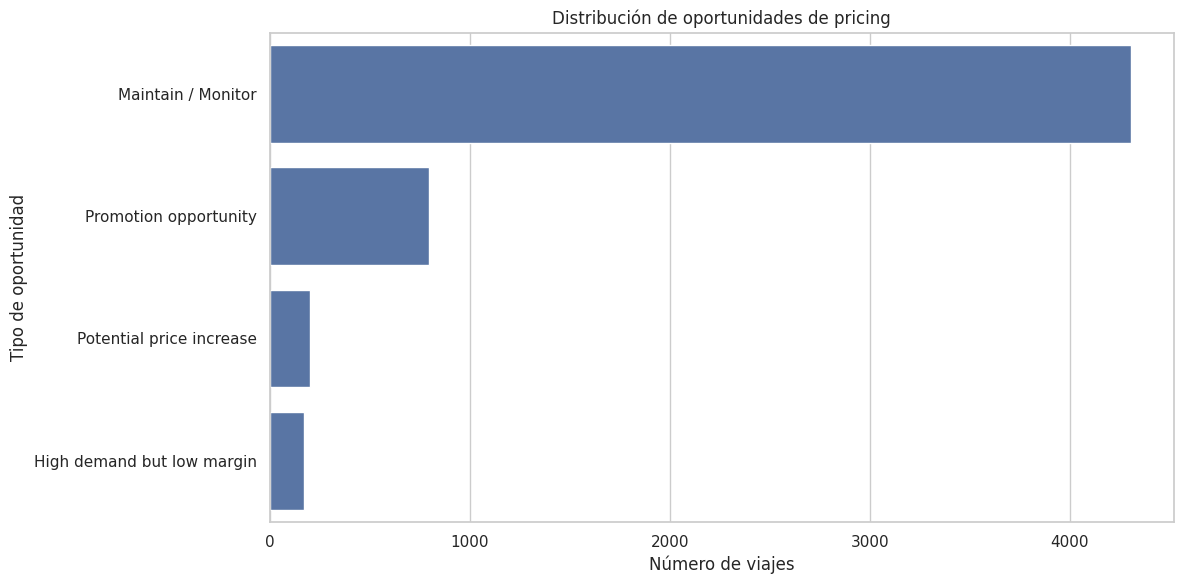

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pricing_counts,
    x="count",
    y="pricing_opportunity"
)

plt.title("Distribución de oportunidades de pricing")
plt.xlabel("Número de viajes")
plt.ylabel("Tipo de oportunidad")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 23. GUARDADO DEL DATASET
# ============================================================

raw_output_path = f"{base_path}/data/raw/ferry_pricing_dataset.csv"
processed_output_path = f"{base_path}/data/processed/ferry_pricing_dataset.csv"

df_final.to_csv(raw_output_path, index=False)
df_final.to_csv(processed_output_path, index=False)

print("Dataset guardado correctamente en:")
print(raw_output_path)
print(processed_output_path)

Dataset guardado correctamente en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/raw/ferry_pricing_dataset.csv
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed/ferry_pricing_dataset.csv


In [25]:
# ============================================================
# 24. COMPROBACIÓN DE LECTURA
# ============================================================

test_df = pd.read_csv(processed_output_path)

print(f"Dataset leído correctamente: {test_df.shape[0]:,} filas y {test_df.shape[1]:,} columnas")
test_df.head()

Dataset leído correctamente: 5,475 filas y 38 columnas


,trip_id,trip_date,departure_datetime,year,month,week,day_of_week,is_weekend,season,high_season_flag,route,origin,destination,route_type,vessel_type,departure_hour,capacity,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor,route_elasticity,days_before_departure,booking_window,weather_score,event_flag,expected_demand,tickets_sold,occupancy_rate,revenue,fixed_operational_cost,variable_cost_per_passenger,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity,trip_feature
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,8,350,58,44.76,42.02,1.065,-0.85,50,Early,7.9,0,189,189,0.5400,8459.64,14500,8,16012,-7552.36,-0.8928,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,14,350,58,57.35,57.26,1.002,-0.85,34,Medium,7.0,0,160,160,0.4571,9176.00,14500,8,15780,-6604.00,-0.7197,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,20,350,58,56.78,62.52,0.908,-0.85,9,Short,8.1,0,195,195,0.5571,11072.10,14500,8,16060,-4987.90,-0.4505,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,9,280,72,66.93,66.98,0.999,-0.75,24,Medium,9.3,0,160,160,0.5714,10708.80,13200,7,14320,-3611.20,-0.3372,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,17,280,72,64.16,63.41,1.012,-0.75,36,Medium,6.9,0,131,131,0.4679,8404.96,13200,7,14117,-5712.04,-0.6796,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [26]:
# ============================================================
# 25. DICCIONARIO DE DATOS
# ============================================================

data_dictionary = pd.DataFrame({
    "column": df_final.columns,
    "description": [
        "Identificador único del viaje",
        "Fecha del viaje",
        "Fecha y hora exacta de salida",
        "Año del viaje",
        "Mes del viaje",
        "Semana ISO del año",
        "Día de la semana",
        "Indicador de fin de semana comercial",
        "Temporada: Low, Shoulder o High",
        "Indicador binario de temporada alta",
        "Ruta comercial",
        "Puerto de origen",
        "Puerto de destino",
        "Tipo de ruta",
        "Tipo de ferry",
        "Hora de salida",
        "Capacidad máxima de pasajeros",
        "Precio base de referencia",
        "Precio medio real del ticket",
        "Precio medio estimado del competidor",
        "Índice de precio frente al competidor",
        "Elasticidad precio-demanda estimada de la ruta",
        "Antelación media de compra",
        "Ventana de reserva",
        "Indicador meteorológico simulado de 1 a 10",
        "Indicador de evento especial",
        "Demanda esperada antes de limitar por capacidad",
        "Tickets vendidos",
        "Ratio de ocupación del ferry",
        "Ingresos del viaje",
        "Coste fijo operativo por viaje",
        "Coste variable por pasajero",
        "Coste operativo total",
        "Margen absoluto del viaje",
        "Margen porcentual del viaje",
        "Nivel de demanda según ocupación",
        "Clasificación de oportunidad de pricing",
        "Variable combinada para análisis segmentado"
    ]
})

data_dictionary

,column,description
0,trip_id,Identificador único del viaje
1,trip_date,Fecha del viaje
2,departure_datetime,Fecha y hora exacta de salida
3,year,Año del viaje
4,month,Mes del viaje
5,week,Semana ISO del año
6,day_of_week,Día de la semana
7,is_weekend,Indicador de fin de semana comercial
8,season,"Temporada: Low, Shoulder o High"
9,high_season_flag,Indicador binario de temporada alta


In [27]:
dictionary_path = f"{base_path}/reports/data_dictionary_pricing.csv"

data_dictionary.to_csv(dictionary_path, index=False)

print("Diccionario de datos guardado en:")
print(dictionary_path)

Diccionario de datos guardado en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports/data_dictionary_pricing.csv


## Conclusiones del Notebook 1

En este primer notebook se ha generado un dataset simulado para analizar pricing y revenue management en una compañía ficticia de transporte marítimo.

El dataset contiene información a nivel de viaje, incluyendo variables temporales, comerciales, operativas y financieras.

Entre las principales variables generadas se encuentran:

- Ruta.
- Fecha y hora de salida.
- Temporada.
- Capacidad.
- Precio base.
- Precio medio del ticket.
- Precio de competidor.
- Elasticidad estimada.
- Antelación media de compra.
- Demanda esperada.
- Tickets vendidos.
- Ocupación.
- Revenue.
- Costes operativos.
- Margen.
- Oportunidades de pricing.

Este dataset será la base para los siguientes notebooks, donde se analizará el comportamiento de la demanda, la sensibilidad al precio, los escenarios de simulación y las recomendaciones de pricing.

In [28]:
display(routes_df)

,route,origin,destination,route_type,vessel_type,capacity,base_price,base_demand,fixed_operational_cost,variable_cost_per_passenger,elasticity,departures
0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,350,58,250,14500,8,-0.85,"[8, 14, 20]"
1,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,280,72,190,13200,7,-0.75,"[9, 17]"
2,Denia-Mallorca,Denia,Mallorca,Mainland-Island,Ro-Pax,520,64,310,22500,10,-0.95,"[11, 22]"
3,Valencia-Ibiza,Valencia,Ibiza,Mainland-Island,Ro-Pax,620,69,390,25500,11,-0.90,"[10, 23]"
4,Valencia-Mallorca,Valencia,Mallorca,Mainland-Island,Ro-Pax,700,62,440,27500,12,-1.05,"[8, 16, 23]"
5,Ibiza-Mallorca,Ibiza,Mallorca,Inter-island,Fast Ferry,300,49,180,11800,7,-1.15,"[7, 13, 19]"


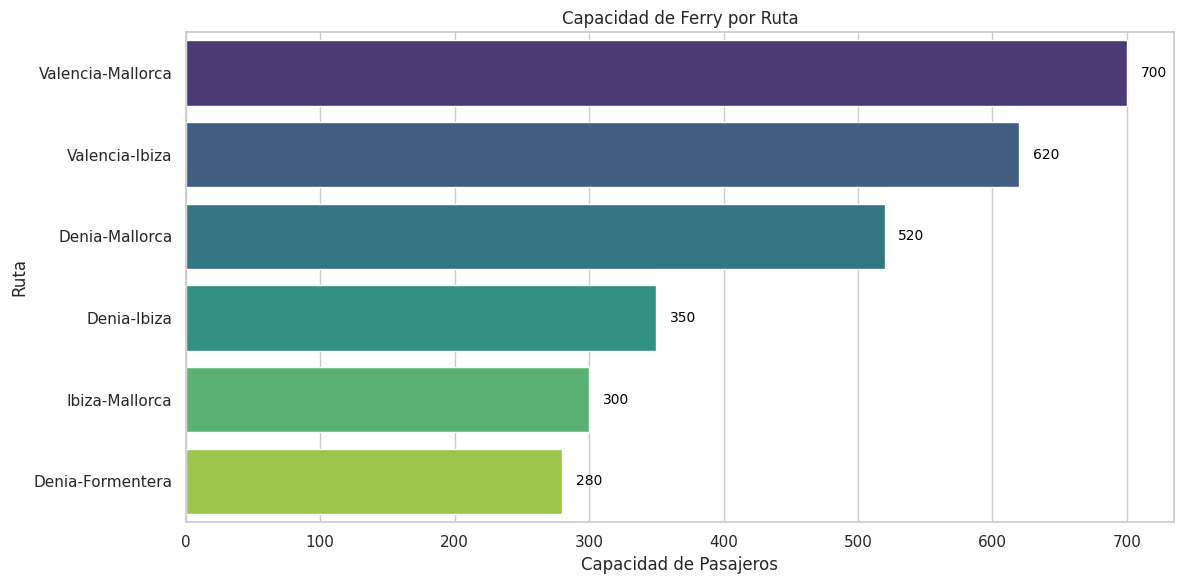

In [29]:
plt.figure(figsize=(12, 6))

# Sort the DataFrame by capacity in descending order to match the barplot's default sorting
routes_df_sorted = routes_df.sort_values(by="capacity", ascending=False).reset_index(drop=True)

sns.barplot(
    data=routes_df_sorted,
    x="capacity",
    y="route",
    palette="viridis"
)

plt.title("Capacidad de Ferry por Ruta")
plt.xlabel("Capacidad de Pasajeros")
plt.ylabel("Ruta")

# Add values at the end of the bars
# Iterate over the sorted DataFrame's capacity and use its index for y-position
for i, capacity_value in enumerate(routes_df_sorted['capacity']):
    # The x-position should be the capacity_value, plus a small offset for better visibility
    # The y-position is 'i' because the bars are plotted in this order.
    plt.text(capacity_value + 10, i, f'{capacity_value}', va='center', ha='left', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Distribución de `margin_pct` por ruta

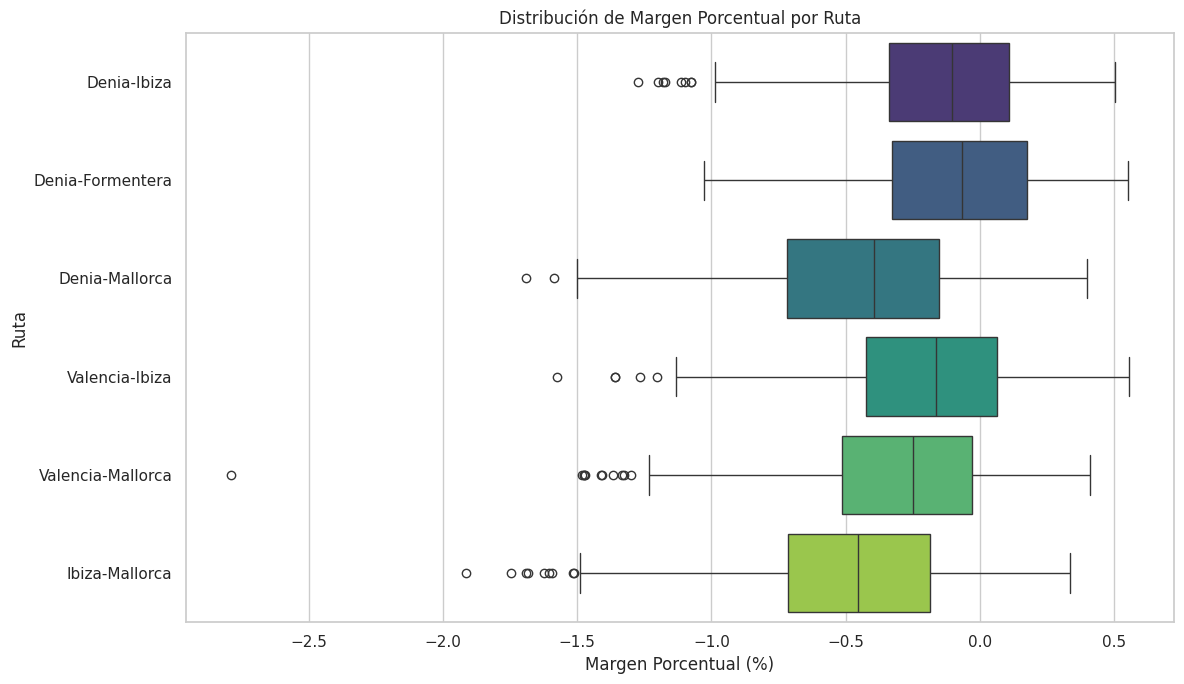

In [31]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_final,
    x="margin_pct",
    y="route",
    palette="viridis"
)
plt.title("Distribución de Margen Porcentual por Ruta")
plt.xlabel("Margen Porcentual (%)")
plt.ylabel("Ruta")
plt.tight_layout()
plt.show()

In [32]:
df_final=[avg_margin_pct]

NameError: name 'avg_margin_pct' is not defined